# Notebook 03: Ajuste Nelson-Siegel

Ajuste diario del modelo Nelson-Siegel a la curva de tasas reales, separado por grupo.

**Objetivo:** Obtener los parámetros estructurales β₀, β₁, β₂, λ que describen la forma de la curva cada día. Son el insumo principal del autoencoder (Notebook 06).

**Contenido:**
1. Ajuste NS — LECER (todos los datos disponibles)
2. Ajuste NS — CER (desde 2025-12-08, régimen actual definido en NB02)
3. Evolución temporal de parámetros por grupo
4. Curvas ajustadas vs datos reales (muestra de fechas)
5. Residuales por bono

**Modelo Nelson-Siegel:**

$$y(\tau) = \beta_0 + \beta_1 \cdot \frac{1-e^{-\tau/\lambda}}{\tau/\lambda} + \beta_2 \cdot \left(\frac{1-e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda}\right)$$

- **β₀** = nivel de largo plazo  
- **β₁** = pendiente (short − long rate); negativo en curva ascendente  
- **β₂** = curvatura (joroba o valle)  
- **λ** = constante de decaimiento (escala temporal, en años)

Para **LECER** (durations 0.2–1.2 años) se fija λ = 1.0 para que β₀, β₁, β₂ sean comparables día a día sin inestabilidad numérica.  
Para **CER** (durations 0.07–9.5 años) λ es libre.

In [81]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, '.env'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
from sqlalchemy import text
from src.db.session import SessionLocal

print('Setup OK')

Setup OK


In [82]:

# ─────────────────────────────────────────
#  PARÁMETROS — modificar acá
# ─────────────────────────────────────────
FECHA_INICIO_LECER = '2026-02-02'
FECHA_INICIO_CER   = '2025-12-08'   # régimen actual (postulado en NB02)

MIN_BONOS_LECER  = 5   # mínimo de bonos LECER vigentes por día para incluir esa fecha
MIN_PUNTOS_CER   = 4   # mínimo de bonos CER para el ajuste NS

LAM_FIJO_LECER = None  # λ libre


In [83]:

with SessionLocal() as db:
    df_lecer = pd.read_sql(
        text("""
            SELECT p.ticker, p.fecha, m.tir, m.duration_modificada
            FROM precios_raw p
            JOIN metricas_diarias m ON m.precio_id = p.id
            JOIN bonos b ON b.ticker = p.ticker
            WHERE b.grupo = 'lecer'
              AND p.fecha >= :inicio
            ORDER BY p.fecha, m.duration_modificada
        """),
        db.bind,
        params={'inicio': FECHA_INICIO_LECER},
        parse_dates=['fecha']
    )
    df_cer = pd.read_sql(
        text("""
            SELECT p.ticker, p.fecha, m.tir, m.duration_modificada
            FROM precios_raw p
            JOIN metricas_diarias m ON m.precio_id = p.id
            JOIN bonos b ON b.ticker = p.ticker
            WHERE b.grupo = 'cer'
              AND p.fecha >= :inicio
            ORDER BY p.fecha, m.duration_modificada
        """),
        db.bind,
        params={'inicio': FECHA_INICIO_CER},
        parse_dates=['fecha']
    )

for _df in (df_lecer, df_cer):
    _df['tir']                = _df['tir'].astype(float)
    _df['duration_modificada'] = _df['duration_modificada'].astype(float)

df_lecer = df_lecer.dropna(subset=['tir', 'duration_modificada'])
df_cer   = df_cer.dropna(subset=['tir', 'duration_modificada'])

print(f'LECER: {len(df_lecer):,} obs  |  {df_lecer["fecha"].min().date()} → {df_lecer["fecha"].max().date()}')
print(f'CER:   {len(df_cer):,} obs  |  {df_cer["fecha"].min().date()} → {df_cer["fecha"].max().date()}')
print(f'\nLECER tickers ({df_lecer["ticker"].nunique()}): {sorted(df_lecer["ticker"].unique())}')
print(f'CER   tickers ({df_cer["ticker"].nunique()}): {sorted(df_cer["ticker"].unique())}')


LECER: 107 obs  |  2026-02-02 → 2026-03-04
CER:   884 obs  |  2025-12-09 → 2026-03-04

LECER tickers (6): ['TZXA7', 'TZXY7', 'X15Y6', 'X29Y6', 'X30N6', 'X31L6']
CER   tickers (16): ['CUAP', 'DICP', 'DIP0', 'PAP0', 'PARP', 'TX26', 'TX28', 'TX31', 'TZX26', 'TZX27', 'TZX28', 'TZXD6', 'TZXD7', 'TZXM6', 'TZXM7', 'TZXO6']


In [84]:
# ── Modelo Nelson-Siegel + ajustador por día ─────────────────

def nelson_siegel(tau, beta0, beta1, beta2, lam):
    """y(τ) = β₀ + β₁·f₁(τ/λ) + β₂·f₂(τ/λ)"""
    with np.errstate(over='ignore', invalid='ignore'):
        x  = tau / lam
        f1 = np.where(x < 1e-10, 1.0, (1.0 - np.exp(-x)) / x)
        f2 = f1 - np.exp(-x)
    return beta0 + beta1 * f1 + beta2 * f2


def ajustar_ns_dia(df_dia, lam_fijo=None, min_puntos=3):
    """
    Ajusta NS a un corte diario.
    Retorna dict con beta0, beta1, beta2, lam, rmse_pp y residuales por ticker (en pp).
    Retorna None si hay pocos datos o el ajuste falla.
    """
    df_dia = df_dia[df_dia['duration_modificada'] > 0].dropna(subset=['tir', 'duration_modificada'])
    if len(df_dia) < min_puntos:
        return None

    d       = df_dia['duration_modificada'].values
    y       = df_dia['tir'].values
    tickers = df_dia['ticker'].values

    # Inicialización inteligente: pendiente desde bono más corto al más largo
    idx = np.argsort(d)
    slope_init = float(y[idx[0]] - y[idx[-1]])

    try:
        if lam_fijo is not None:
            def ns_fixed(tau, b0, b1, b2):
                return nelson_siegel(tau, b0, b1, b2, lam_fijo)
            popt, _ = curve_fit(
                ns_fixed, d, y,
                p0=[float(np.mean(y)), slope_init, 0.0],
                bounds=([-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]),
                maxfev=5000
            )
            beta0, beta1, beta2 = popt
            lam = lam_fijo
        else:
            popt, _ = curve_fit(
                nelson_siegel, d, y,
                p0=[float(np.mean(y)), slope_init, 0.0, 1.0],
                bounds=([-0.5, -0.5, -0.5, 0.05], [0.5, 0.5, 0.5, 10.0]),
                maxfev=5000
            )
            beta0, beta1, beta2, lam = popt
    except Exception:
        return None

    y_pred    = nelson_siegel(d, beta0, beta1, beta2, lam)
    resid_pp  = (y - y_pred) * 100   # puntos porcentuales
    rmse_pp   = float(np.sqrt(np.mean(resid_pp ** 2)))

    return {
        'beta0':      beta0,
        'beta1':      beta1,
        'beta2':      beta2,
        'lam':        lam,
        'rmse_pp':    rmse_pp,
        'residuales': dict(zip(tickers, resid_pp)),
    }


print('Funciones NS cargadas')

Funciones NS cargadas


In [85]:

# ── 1. Ajuste LECER ───────────────────────────────────────────
resultados_lecer = {}
for fecha, grupo in df_lecer.groupby('fecha'):
    res = ajustar_ns_dia(grupo, lam_fijo=LAM_FIJO_LECER, min_puntos=MIN_BONOS_LECER)
    if res is not None:
        resultados_lecer[fecha] = res

params_lecer = pd.DataFrame(
    {f: {k: v for k, v in r.items() if k != 'residuales'} for f, r in resultados_lecer.items()}
).T
params_lecer.index = pd.to_datetime(params_lecer.index)
params_lecer = params_lecer.astype(float).sort_index()

# Residuales LECER en formato largo
resid_lecer = pd.DataFrame([
    {'fecha': f, 'ticker': t, 'residual_pp': r}
    for f, res in resultados_lecer.items()
    for t, r in res['residuales'].items()
])

dias_total = df_lecer['fecha'].nunique()
print(f'LECER ajustados: {len(params_lecer)} / {dias_total} días ({len(params_lecer)/dias_total*100:.0f}%)')
print(f'λ fijo: {LAM_FIJO_LECER}')
params_lecer.describe().round(4)


LECER ajustados: 20 / 21 días (95%)
λ fijo: None


,beta0,beta1,beta2,lam,rmse_pp
count,20.0000,20.0000,20.0000,20.0000,20.0000
mean,-0.0416,-0.0946,0.4533,0.3311,1.0075
std,0.0652,0.1326,0.0826,0.1116,0.5545
min,-0.1227,-0.5000,0.2174,0.0940,0.1640
25%,-0.0808,-0.1381,0.4234,0.2970,0.7114
50%,-0.0722,-0.0499,0.5000,0.3515,0.8587
75%,0.0185,-0.0234,0.5000,0.3790,1.5374
max,0.0933,0.0634,0.5000,0.5799,1.9722


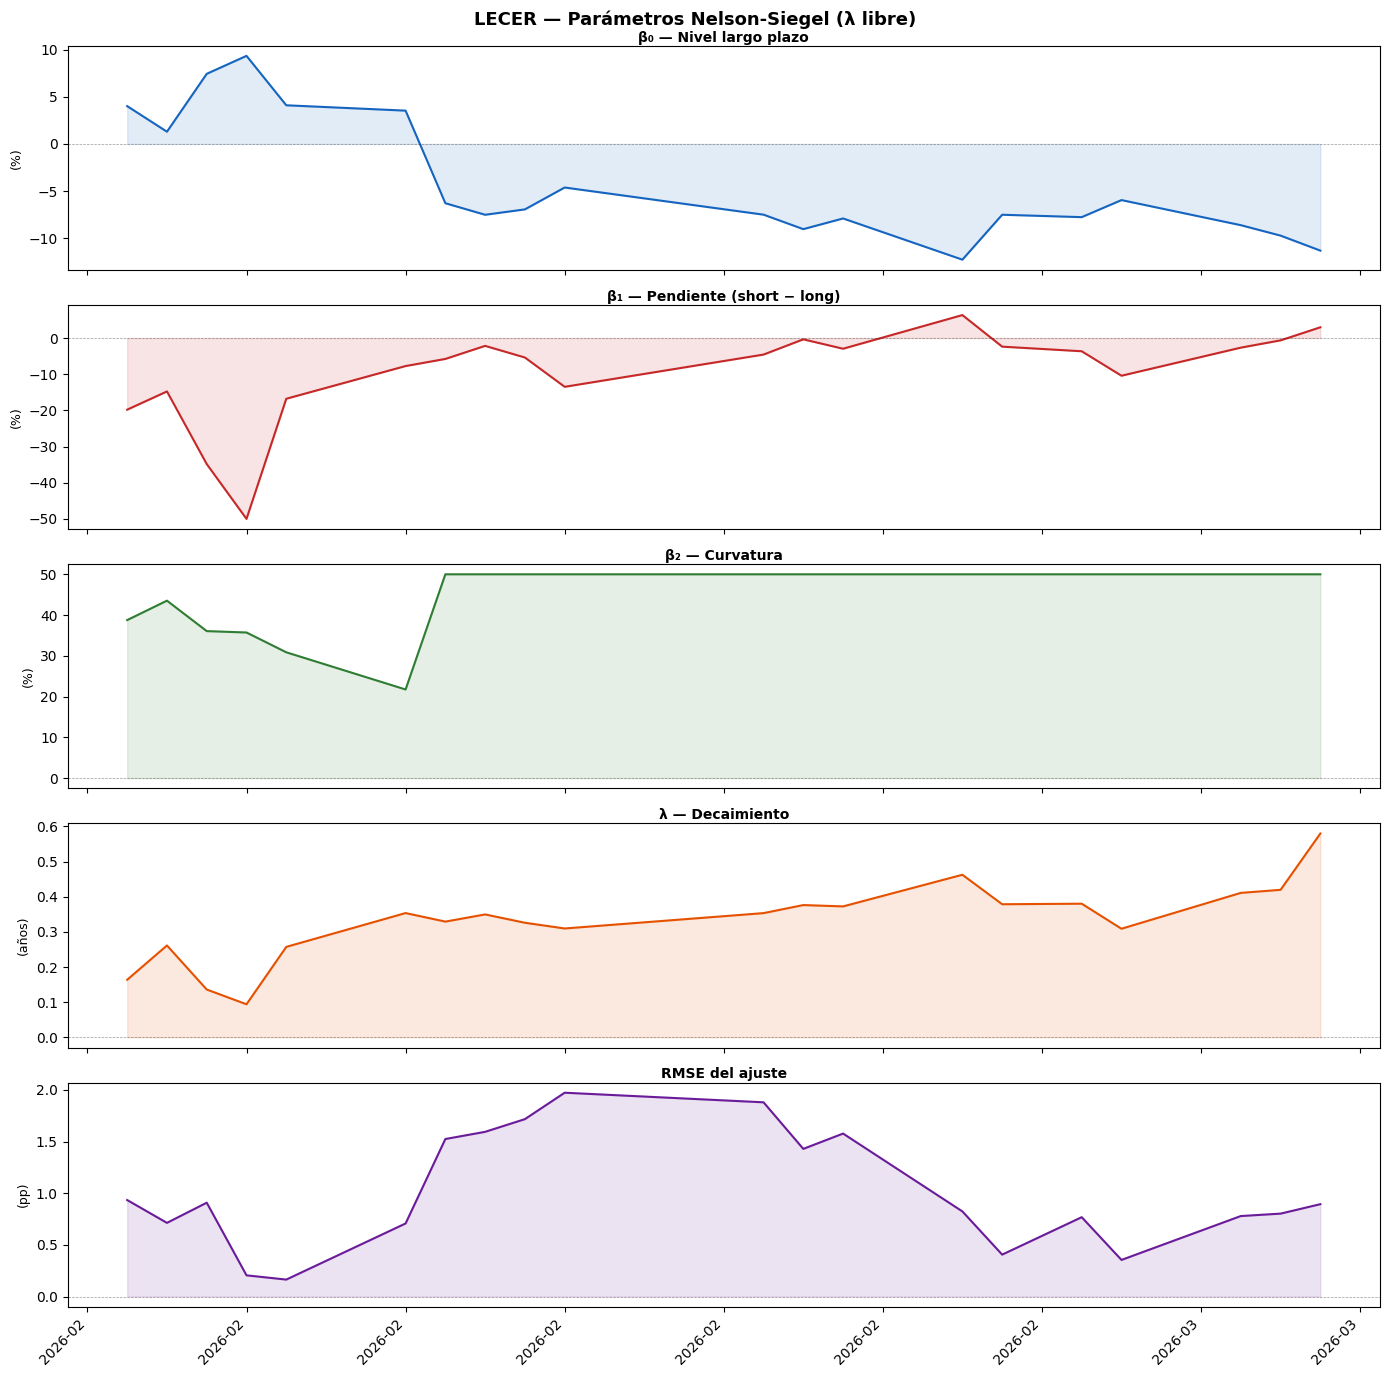

In [86]:

# Evolución de parámetros NS — LECER
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

def _plot_param(ax, serie, titulo, color, ylabel):
    ax.plot(serie.index, serie.values, color=color, linewidth=1.5)
    ax.fill_between(serie.index, serie.values, alpha=0.12, color=color)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    ax.set_title(titulo, fontsize=10, fontweight='bold', pad=3)
    ax.set_ylabel(ylabel, fontsize=9)

_plot_param(axes[0], params_lecer['beta0'] * 100, 'β₀ — Nivel largo plazo', '#1565C0', '(%)')
_plot_param(axes[1], params_lecer['beta1'] * 100, 'β₁ — Pendiente (short − long)', '#C62828', '(%)')
_plot_param(axes[2], params_lecer['beta2'] * 100, 'β₂ — Curvatura', '#2E7D32', '(%)')
_plot_param(axes[3], params_lecer['lam'],          'λ — Decaimiento', '#E65100', '(años)')
_plot_param(axes[4], params_lecer['rmse_pp'],      'RMSE del ajuste', '#6A1B9A', '(pp)')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('LECER — Parámetros Nelson-Siegel (λ libre)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [87]:
# ── 2. Ajuste CER ─────────────────────────────────────────────
resultados_cer = {}
for fecha, grupo in df_cer.groupby('fecha'):
    res = ajustar_ns_dia(grupo, lam_fijo=None, min_puntos=MIN_PUNTOS_CER)
    if res is not None:
        resultados_cer[fecha] = res

params_cer = pd.DataFrame(
    {f: {k: v for k, v in r.items() if k != 'residuales'} for f, r in resultados_cer.items()}
).T
params_cer.index = pd.to_datetime(params_cer.index)
params_cer = params_cer.astype(float).sort_index()

# Residuales CER en formato largo
resid_cer = pd.DataFrame([
    {'fecha': f, 'ticker': t, 'residual_pp': r}
    for f, res in resultados_cer.items()
    for t, r in res['residuales'].items()
])

dias_total = df_cer['fecha'].nunique()
print(f'CER ajustados: {len(params_cer)} / {dias_total} días ({len(params_cer)/dias_total*100:.0f}%)')
params_cer.describe().round(4)

CER ajustados: 56 / 56 días (100%)


/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_73009/3262051996.py:43: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


,beta0,beta1,beta2,lam,rmse_pp
count,56.0000,56.0000,56.0000,56.0000,56.0000
mean,0.0783,-0.1207,0.0779,0.4085,0.4333
std,0.0423,0.0748,0.0807,1.2036,0.2764
min,-0.2323,-0.2788,-0.0001,0.0500,0.0823
25%,0.0829,-0.1589,0.0000,0.1940,0.2525
50%,0.0840,-0.1231,0.0828,0.2456,0.3152
75%,0.0855,-0.0921,0.1072,0.3000,0.5655
max,0.0893,0.2867,0.5000,9.2331,0.9736


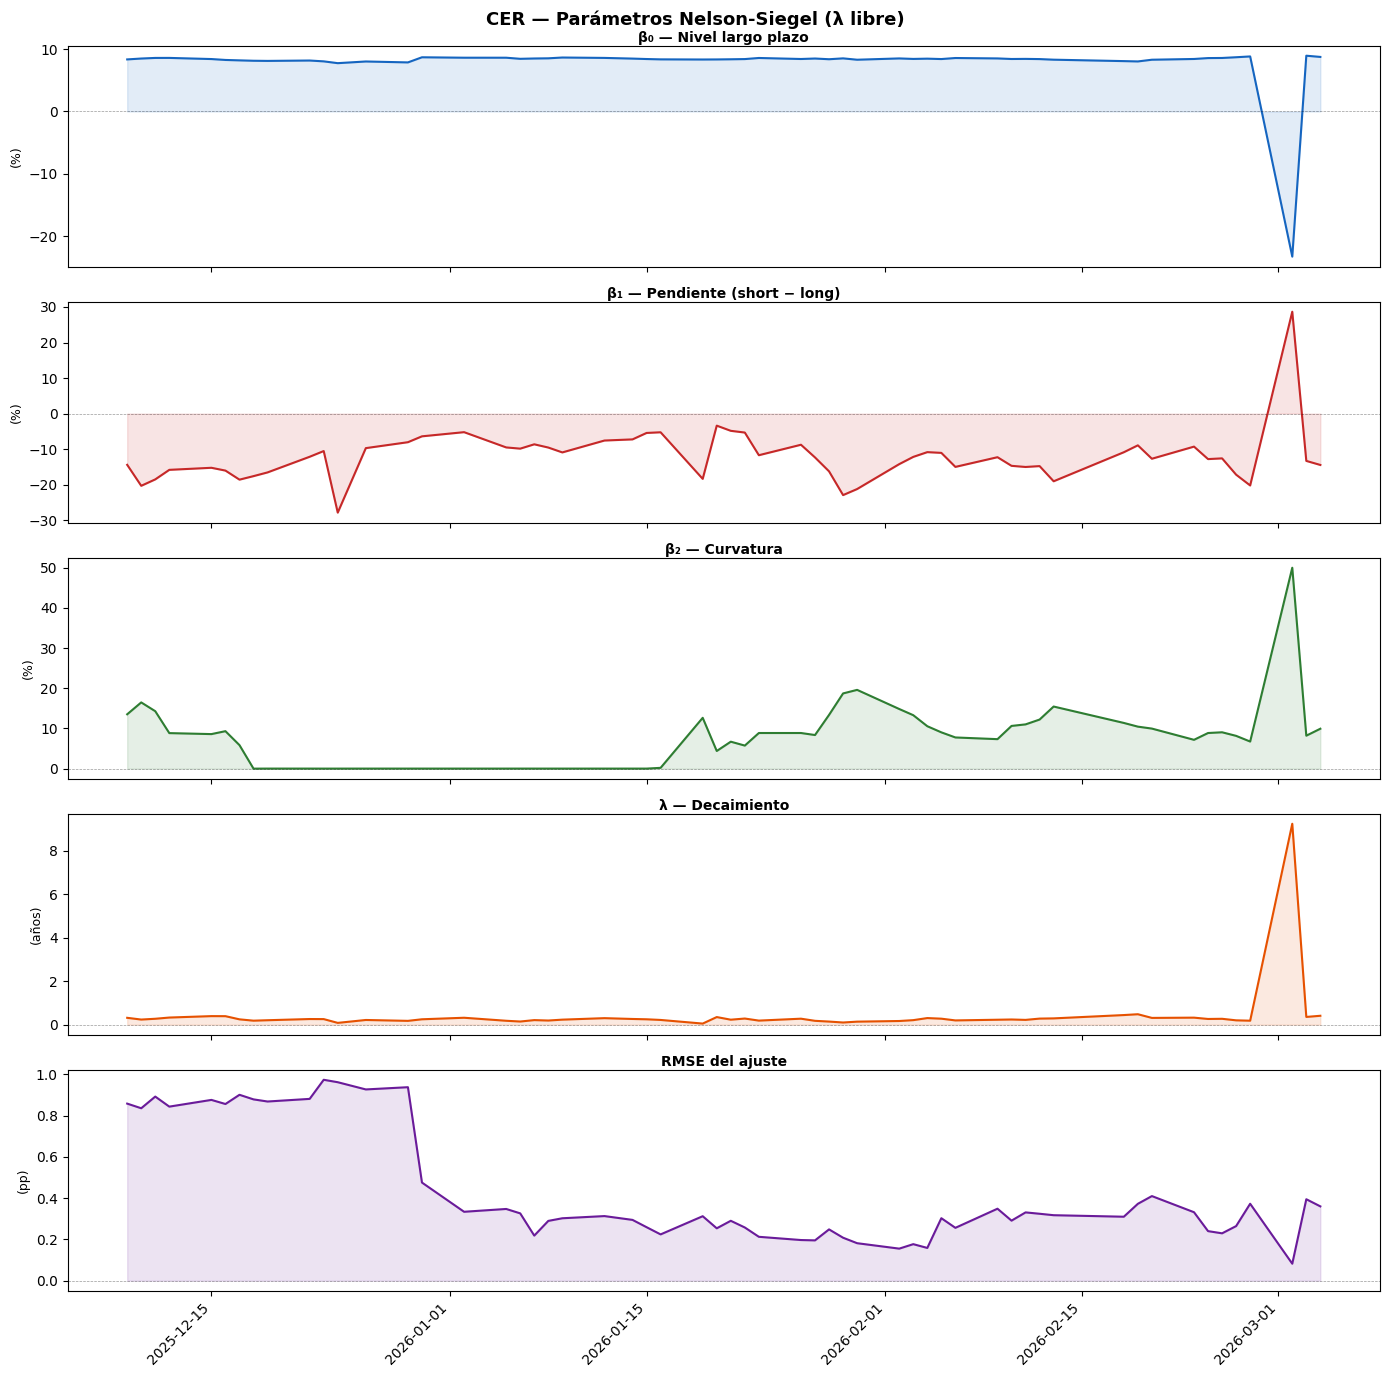

In [88]:
# Evolución de parámetros NS — CER
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

_plot_param(axes[0], params_cer['beta0'] * 100, 'β₀ — Nivel largo plazo', '#1565C0', '(%)')
_plot_param(axes[1], params_cer['beta1'] * 100, 'β₁ — Pendiente (short − long)', '#C62828', '(%)')
_plot_param(axes[2], params_cer['beta2'] * 100, 'β₂ — Curvatura', '#2E7D32', '(%)')
_plot_param(axes[3], params_cer['lam'],          'λ — Decaimiento', '#E65100', '(años)')
_plot_param(axes[4], params_cer['rmse_pp'],      'RMSE del ajuste', '#6A1B9A', '(pp)')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('CER — Parámetros Nelson-Siegel (λ libre)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

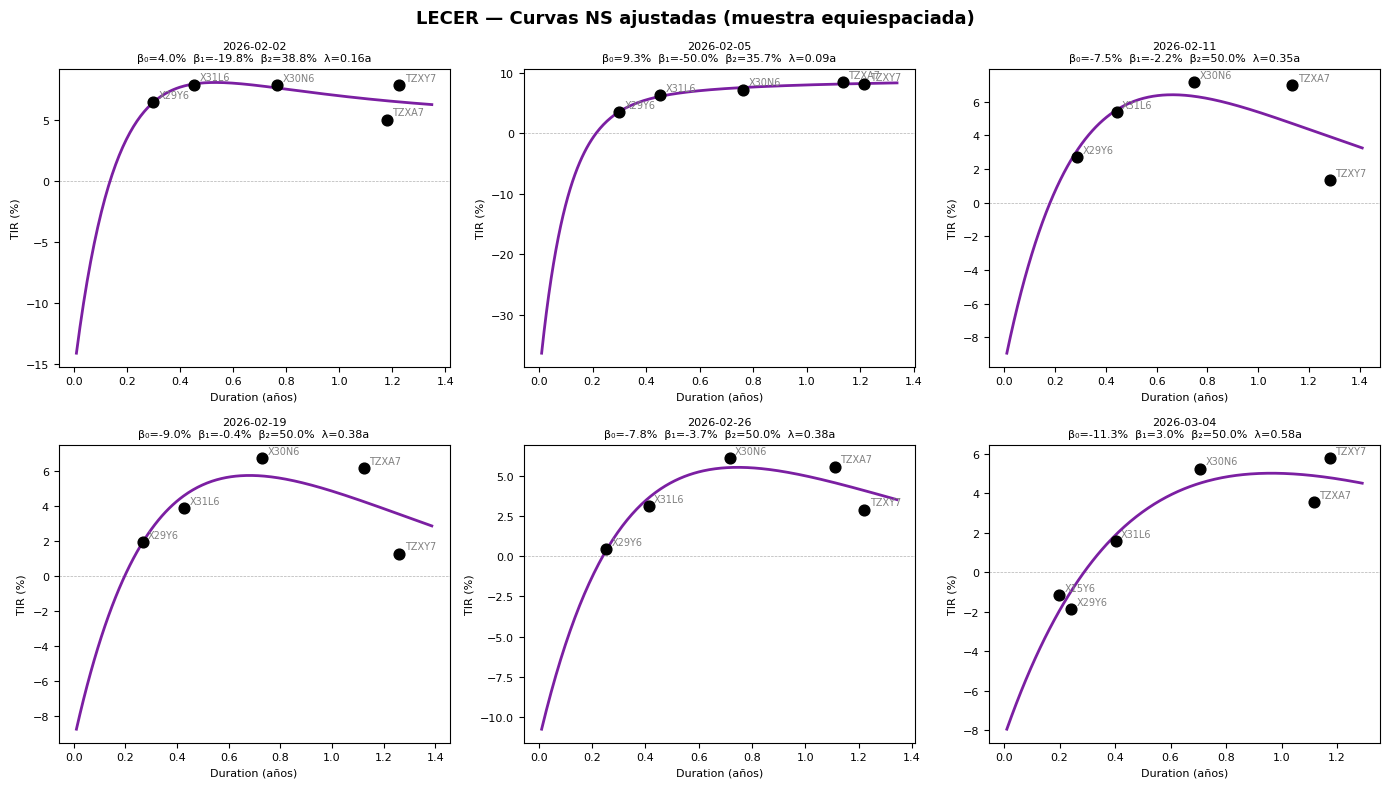

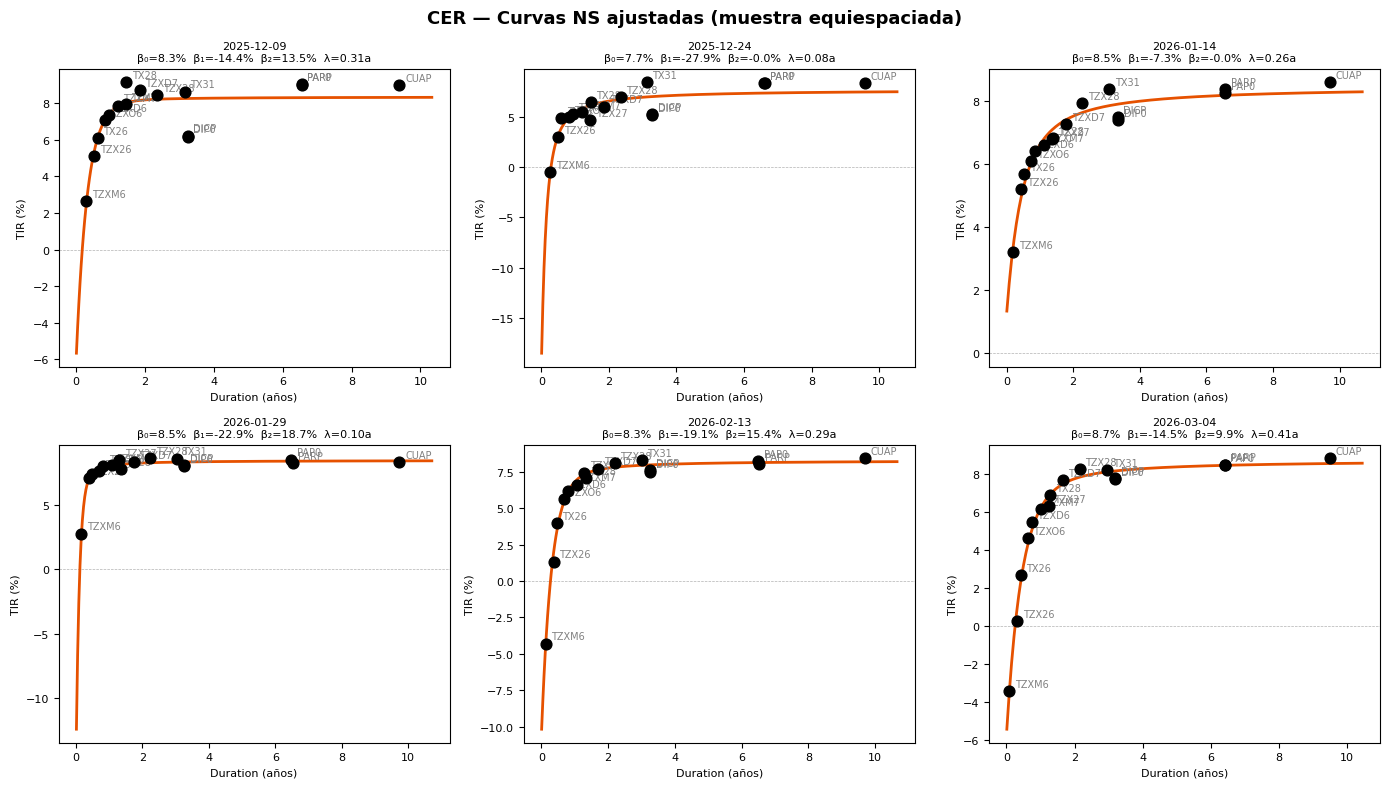

In [89]:

# ── Curvas ajustadas — muestra de fechas ─────────────────────
# Selecciona N fechas equiespaciadas para cada grupo y muestra
# los puntos reales + la curva NS ajustada.

def plot_curvas_ajustadas(df_raw, resultados, titulo, n_fechas=6, color='#1565C0'):
    fechas_disp = sorted(resultados.keys())
    if len(fechas_disp) == 0:
        print(f'Sin resultados para {titulo}')
        return
    indices    = np.linspace(0, len(fechas_disp) - 1, min(n_fechas, len(fechas_disp)), dtype=int)
    fechas_sel = [fechas_disp[i] for i in indices]

    ncols = 3
    nrows = int(np.ceil(len(fechas_sel) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, fecha in zip(axes, fechas_sel):
        res   = resultados[fecha]
        corte = df_raw[df_raw['fecha'] == fecha].sort_values('duration_modificada')

        d_max = float(corte['duration_modificada'].max()) * 1.1
        tau   = np.linspace(0.01, max(d_max, 0.5), 300)
        y_ns  = nelson_siegel(tau, res['beta0'], res['beta1'], res['beta2'], res['lam']) * 100

        ax.plot(tau, y_ns, color=color, linewidth=2, label='NS fit', zorder=3)
        ax.scatter(corte['duration_modificada'], corte['tir'] * 100,
                   color='black', s=60, zorder=5, label='datos')
        for _, row in corte.iterrows():
            ax.annotate(row['ticker'],
                        (row['duration_modificada'], row['tir'] * 100),
                        textcoords='offset points', xytext=(4, 3), fontsize=7, color='gray')

        b0, b1, b2, lam = res['beta0']*100, res['beta1']*100, res['beta2']*100, res['lam']
        ax.set_title(f"{fecha.date()}\nβ₀={b0:.1f}%  β₁={b1:.1f}%  β₂={b2:.1f}%  λ={lam:.2f}a",
                     fontsize=8)
        ax.set_xlabel('Duration (años)', fontsize=8)
        ax.set_ylabel('TIR (%)', fontsize=8)
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=8)

    for ax in axes[len(fechas_sel):]:
        ax.set_visible(False)

    plt.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_curvas_ajustadas(df_lecer, resultados_lecer,
                      'LECER — Curvas NS ajustadas (muestra equiespaciada)',
                      n_fechas=6, color='#7B1FA2')

plot_curvas_ajustadas(df_cer, resultados_cer,
                      'CER — Curvas NS ajustadas (muestra equiespaciada)',
                      n_fechas=6, color='#E65100')


/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_73009/900149839.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=tickers_ord, patch_artist=True,
/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_73009/900149839.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=tickers_ord, patch_artist=True,


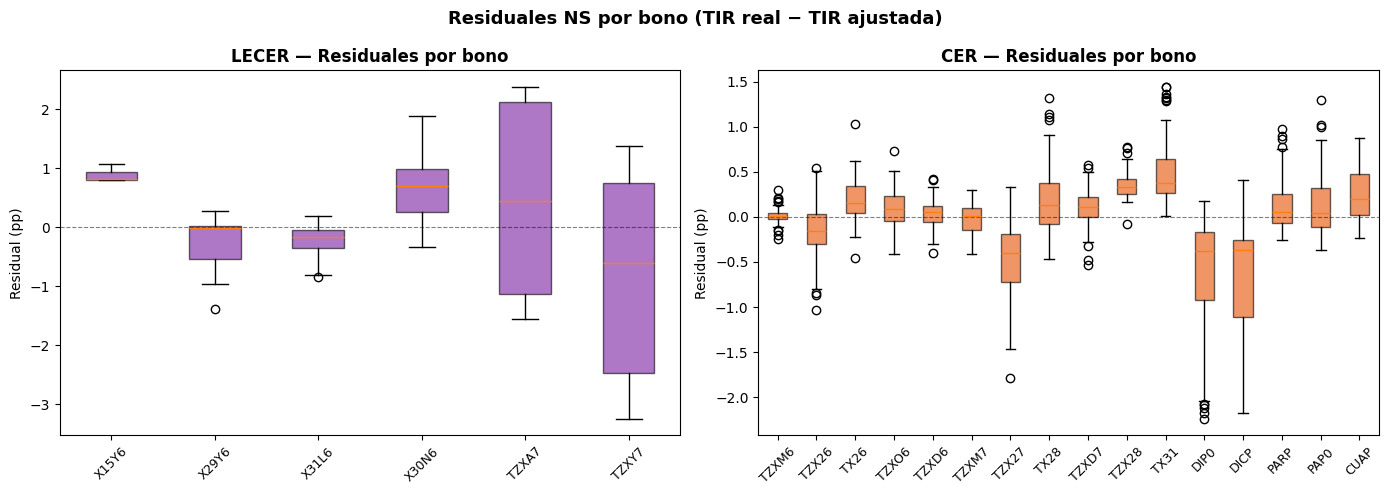

=== LECER ===
         mean    std    min    max
ticker                            
TZXA7   0.515  1.471 -1.546  2.380
TZXY7  -0.813  1.598 -3.241  1.386
X15Y6   0.896  0.157  0.796  1.076
X29Y6  -0.252  0.440 -1.384  0.271
X30N6   0.660  0.530 -0.328  1.884
X31L6  -0.245  0.320 -0.847  0.188

=== CER ===
         mean    std    min    max
ticker                            
CUAP    0.250  0.275 -0.232  0.871
DICP   -0.735  0.772 -2.171  0.407
DIP0   -0.698  0.778 -2.239  0.175
PAP0    0.169  0.394 -0.368  1.302
PARP    0.168  0.339 -0.261  0.981
TX26    0.182  0.253 -0.458  1.029
TX28    0.217  0.415 -0.470  1.316
TX31    0.516  0.386  0.010  1.443
TZX26  -0.158  0.343 -1.039  0.548
TZX27  -0.470  0.404 -1.783  0.336
TZX28   0.357  0.150 -0.078  0.777
TZXD6   0.042  0.172 -0.401  0.420
TZXD7   0.099  0.230 -0.530  0.574
TZXM6   0.012  0.098 -0.245  0.301
TZXM7  -0.024  0.168 -0.411  0.295
TZXO6   0.094  0.225 -0.412  0.727


In [90]:
# ── Residuales por bono ───────────────────────────────────────
# ¿Qué bonos el modelo NS sistemáticamente sobre/subestima?
# Boxplot por ticker, ordenado por duration media (corto → largo).

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

def _boxplot_residuales(ax, resid_df, df_raw, titulo, color):
    tickers_ord = (
        df_raw.groupby('ticker')['duration_modificada']
        .median()
        .sort_values()
        .index.tolist()
    )
    # Solo incluir tickers que tengan residuales
    tickers_ord = [t for t in tickers_ord if t in resid_df['ticker'].values]
    data  = [resid_df[resid_df['ticker'] == t]['residual_pp'].values for t in tickers_ord]
    bp = ax.boxplot(data, labels=tickers_ord, patch_artist=True,
                    vert=True, notch=False, widths=0.5)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel('Residual (pp)', fontsize=10)
    ax.set_title(titulo, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=9)

_boxplot_residuales(ax1, resid_lecer, df_lecer, 'LECER — Residuales por bono', '#7B1FA2')
_boxplot_residuales(ax2, resid_cer,   df_cer,   'CER — Residuales por bono',   '#E65100')

plt.suptitle('Residuales NS por bono (TIR real − TIR ajustada)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas resumidas
print('=== LECER ===')
print(resid_lecer.groupby('ticker')['residual_pp']
      .agg(['mean','std','min','max']).round(3))
print('\n=== CER ===')
print(resid_cer.groupby('ticker')['residual_pp']
      .agg(['mean','std','min','max']).round(3))

## Comentarios

### LECER
- Con **λ fijo = 1.0**, β₀, β₁, β₂ son directamente comparables entre fechas.
- La curva LECER cubre duraciones 0.2–1.2 años: tramo muy corto donde la distinción NS vs interpolación lineal es sutil.
- Los residuales por bono muestran si alguna letra cotiza sistemáticamente *rich* o *cheap* respecto al ajuste.

### CER
- Con **λ libre** el modelo captura mejor la forma de curva en el rango 0.07–9.5 años.
- Los bonos con amortización (TX26, TX28, TX31) pueden generar residuales mayores por el efecto de los pagos ya realizados sobre la duration.
- Los bonos muy largos (PARP, PAP0, CUAP) tienen baja liquidez y sus residuales pueden ser ruido de precio, no señal de forma de curva.

### Uso en NB06 (Autoencoder)
- **Insumos de forma de curva**: β₀, β₁, β₂, λ de cada grupo cada día.
- **Insumos de dislocación**: residuales por bono (señalan qué instrumento se mueve fuera de la curva).
- El período de entrenamiento del autoencoder debe restringirse a días con buen ajuste (RMSE bajo) para no aprender estados de transición anómalos.